# Milestone 5 — M5C: transport-derived source delta

Milestone 5C converts clean/dirty transport pairs from M5B into a particle-induced
source delta. **Particle records alone are not the source-delta ledger.**

Plan: [`plans/milestone_05/05_particle_plan.md`](../../plans/milestone_05/05_particle_plan.md).  
Guidelines: [`docs/milestone_05_particle_guidelines.md`](../../docs/milestone_05_particle_guidelines.md).

This notebook demonstrates:

1. Clean M4 source deposition.
2. Construction of affected clean/dirty transport pairs.
3. Transport-derived source delta (`compute_transport_source_correction`).
4. Background vs particle-scatter split.
5. Entry scatter / downstream shadow (single particle), then lateral / in-line multi-particle.

Diffusion solves and image deltas are handled in M5D.


In [1]:
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

!pip install --quiet --no-cache-dir "{ROOT}[fem]" -c "{ROOT}/requirements.txt"

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
ROOT=.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from gummybear.geometry import load_stl
from gummybear.optics import (
    OpticalMaterialConfig,
    PointLightConfig,
    SourceSamplingParams,
    deposit_ray_source,
    generate_diffusion_mesh,
    in_object_segments_from_rays,
    make_source_ray_bundle,
    refract_ray_bundle,
)
from gummybear.particles import (
    ParticleSet,
    ParticleSphere,
    build_affected_transport_pairs,
    compute_transport_source_correction,
    intersect_segments_with_particles,
)
from gummybear.paths import display_path
from gummybear_validation import notebook_tools
from gummybear_validation.helpers import assert_live_netgen_mesh
from gummybear_validation.plotting import (
    plot_source_delta_triptych,
    plot_transport_pair_deposition_barcodes,
)
import gummybear_validation.milestone_05.validation as m5_validation


# 2. Source field before addition of particle (M4, "Clean")

M5C starts from the clean M4 transport basis and its clean source deposition.
The particle source delta will be added to this clean field.


In [3]:
STL_PATH = ROOT / "cad" / "proto_bear.stl"

surface_mesh = load_stl(STL_PATH)
diff_mesh = generate_diffusion_mesh(STL_PATH, target_elements=1000)
assert_live_netgen_mesh(diff_mesh)

lo, hi = diff_mesh.bounds
c = diff_mesh.bounds.mean(axis=0)

mat = OpticalMaterialConfig(
    mu_scatter=0.3,
    mu_absorption=0.1,
    n_refractive=1.33,
)

light = PointLightConfig(
    position=(c[0] + 15.0, c[1] + 15.0, hi[2] + 15.0),
    intensity=1.0,
)

source_rays = make_source_ray_bundle(
    light,
    surface_mesh.bounds,
    SourceSamplingParams(n_rays=512, seed=0),
)

entry = refract_ray_bundle(
    surface_mesh,
    source_rays,
    n_from=1.0,
    n_to=mat.n_refractive,
)

segments = in_object_segments_from_rays(surface_mesh, entry.rays)
ray_ids = np.asarray(segments.ray_ids, dtype=int)

n_segments = getattr(segments, "n_segments", len(segments.starts))
print(f"STL={display_path(STL_PATH)}")
print(f"Found {n_segments} in-object transport segment(s).")


STL=cad/proto_bear.stl
Found 432 in-object transport segment(s).


## Energy source deposition from the rays

The energy deposited from the rays will later (M5D) serve for diffusion
simulation. Here it is the baseline for validating alteration by particle presence.


In [4]:
clean_source = deposit_ray_source(
    diff_mesh,
    segments,
    mu_s=mat.mu_scatter,
    mu_a=mat.mu_absorption,
)

E_clean_elem = np.asarray(clean_source.E_scat_elem, dtype=float)
S_clean = E_clean_elem / diff_mesh.volumes

print("Clean source deposition:")
print("  n elements          =", len(E_clean_elem))
print("  total E_clean_elem  =", float(E_clean_elem.sum()))
print("  nonzero elements    =", int(np.count_nonzero(E_clean_elem)))


Clean source deposition:
  n elements          = 2080
  total E_clean_elem  = 0.3438753337951489
  nonzero elements    = 1637


# 3. Define particle and construct transport pairs

A mixed absorbance / scattering particle. M5B builds **one** clean/dirty
`AffectedTransportPair` per hit transport path (`path_id`); that path-level
ledger is the basis for dirty−clean comparison and the M5C source delta.


In [5]:
particles = ParticleSet.from_particles([
    ParticleSphere(
        center=c,
        radius=3.0,
        mu_abs=0.2,
        mu_scat=0.8,
        particle_id="p000_mixed_phoenix",
    ),
])

events = intersect_segments_with_particles(segments.starts, segments.ends, particles)
events = sorted(
    list(events),
    key=lambda ev: (int(ev.segment_index), float(ev.entry_t), int(ev.particle_index)),
)
if not events:
    raise AssertionError("No particle intersection events were found.")

event_segment_indices = np.asarray(sorted({int(ev.segment_index) for ev in events}), dtype=int)
event_path_ids = np.asarray(sorted({int(ray_ids[s]) for s in event_segment_indices}), dtype=int)

print(
    f"Particle intersections: {len(events)} event(s) on "
    f"{len(event_segment_indices)} segment(s) and "
    f"{len(event_path_ids)} transport ray(s)."
)

pair_result = build_affected_transport_pairs(
    segments,
    particles,
    events=events,
    mu_s=mat.mu_scatter,
    mu_a=mat.mu_absorption,
)
pairs = tuple(pair_result.pairs)

print(
    f"Defined transport pairs: {len(pairs)} pair(s) for "
    f"{len(event_path_ids)} particle-hit transport ray(s)."
)
print(
    "Dirty-path background mu: "
    f"mu_s={pair_result.metadata['background_mu_s']}, "
    f"mu_a={pair_result.metadata['background_mu_a']}"
)


Particle intersections: 50 event(s) on 50 segment(s) and 50 transport ray(s).
Defined transport pairs: 50 pair(s) for 50 particle-hit transport ray(s).
Dirty-path background mu: mu_s=0.3, mu_a=0.1


# 4. M5C construction validation

### Scattering intensity along intersection rays (expected)

- Identical scattering before particle entry
- Increased scattering energy deposition at least initially within the particle
- Through the particle, beam energy may decrease so deposited scatter can fall below clean
- Behind the particle, dirty background deposition must be lower than clean (shadow)


Milestone 5C
Test executed: test_particle_creates_downstream_scattering_shadow()

pytest:
../../venv/lib/python3.12/site-packages/gummybear_validation/milestone_05/validation.py . [100%]
============================== 1 passed in 0.63s ===============================

Test proves: For each particle-hit transport path, downstream background scattering behind the
             particle is lower along the particle-altered path than along the corresponding
             clean path.


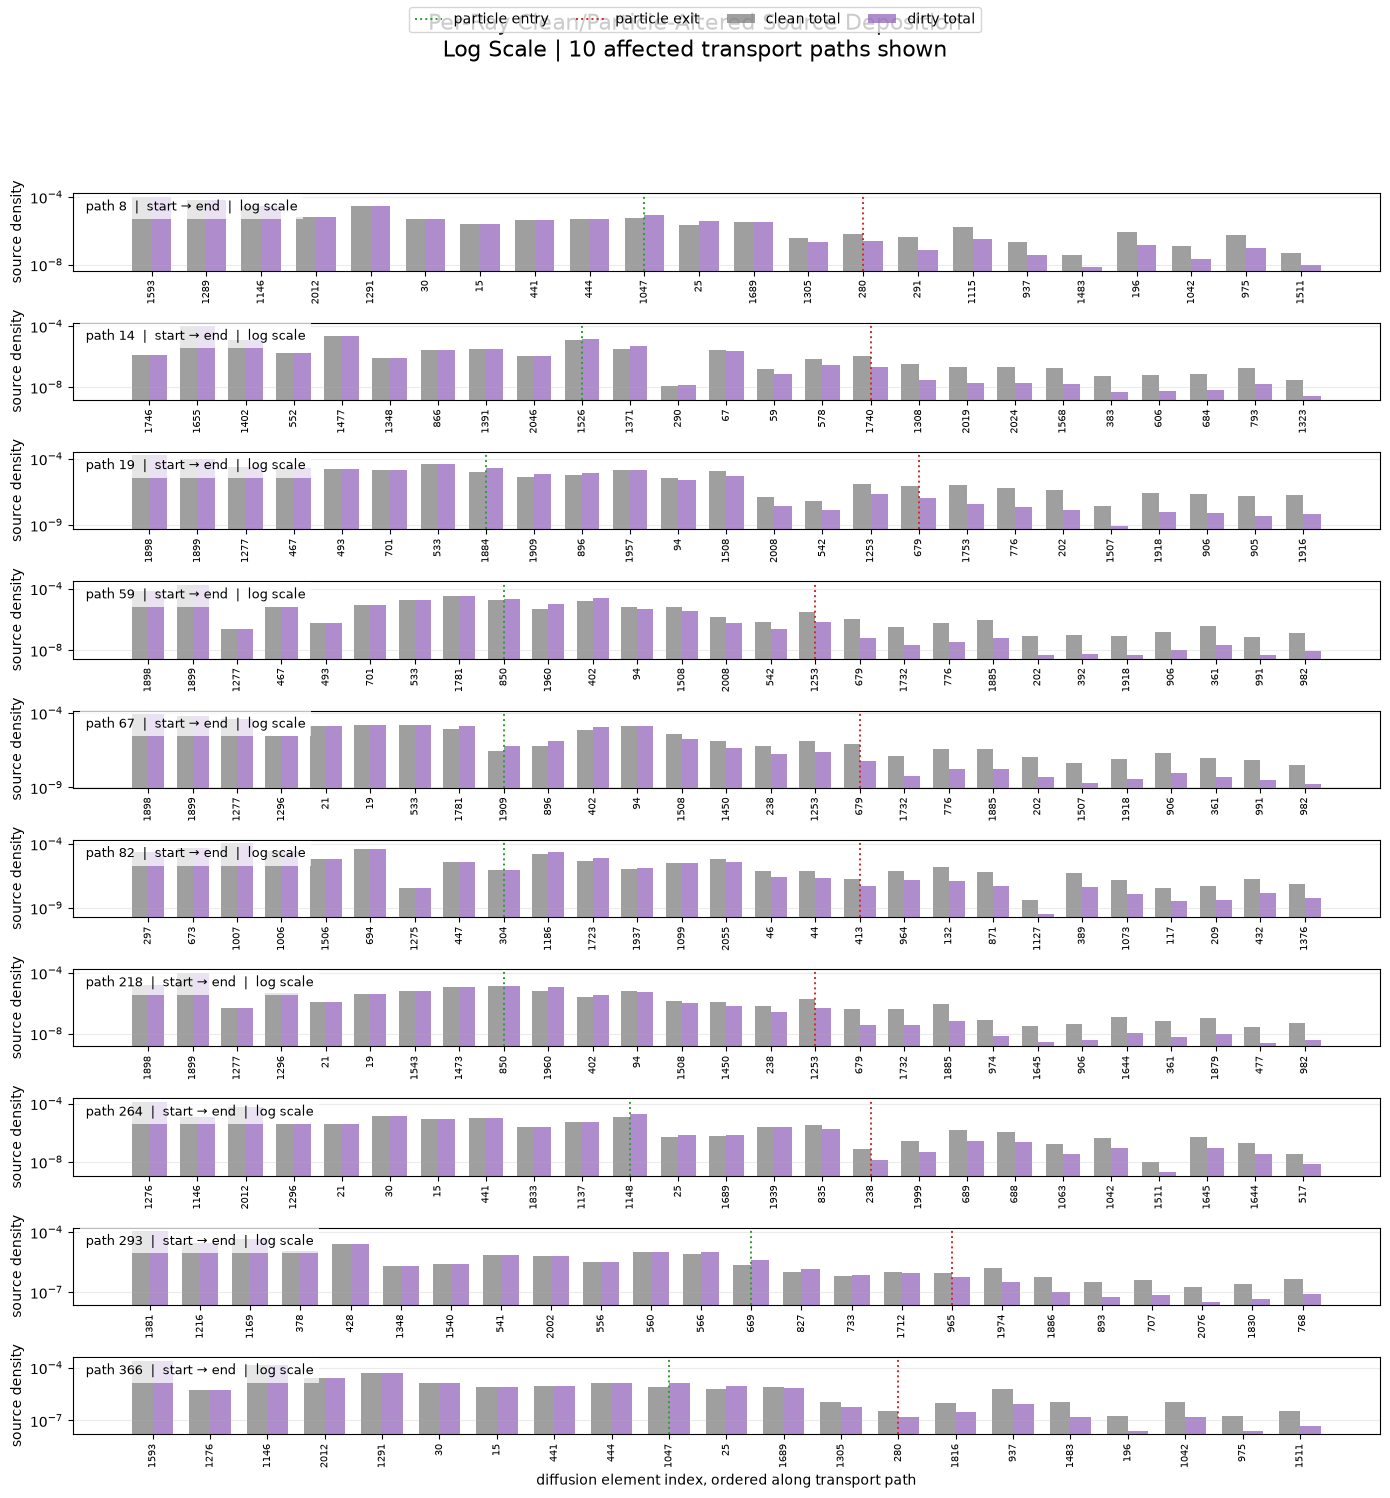

In [6]:
notebook_tools.run_installed_pytest_test(
    m5_validation,
    "test_particle_creates_downstream_scattering_shadow",
)

fig, axes = plot_transport_pair_deposition_barcodes(
    pairs,
    segments,
    events,
    ray_ids,
    diff_mesh,
    mu_s=mat.mu_scatter,
    mu_a=mat.mu_absorption,
    max_rays=10,
    seed=3,
    random_select=True,
    density=True,
    log_scale=True,
)
plt.show()


## 4.2 Overall source delta

The particle source field must arise as the arithmetic sum of:

- Direct beam attenuation by the particle (shadow)
- Scattering from the particle when `mu_s > 0`


In [7]:
notebook_tools.run_installed_pytest_test(
    m5_validation,
    "test_source_correction_identity_and_inspectable_split",
)


Milestone 5C
Test executed: test_source_correction_identity_and_inspectable_split()

pytest:
../../venv/lib/python3.12/site-packages/gummybear_validation/milestone_05/validation.py . [100%]
============================== 1 passed in 0.59s ===============================

Test proves: The particle-induced source delta equals the sum of primary-ray attenuation and
             energy directly scattered by the particle.


# 5. Implementation validation

```text
delta_E_transport_elem
  = delta_E_background_elem
  + delta_E_particle_scat_elem
```


In [8]:
source_delta = compute_transport_source_correction(
    diff_mesh,
    pair_result,
    E_clean_elem,
    mu_s=mat.mu_scatter,
    mu_a=mat.mu_absorption,
)

delta_E_transport_elem = np.asarray(source_delta.delta_E_transport_elem, dtype=float)
delta_E_background_elem = np.asarray(source_delta.delta_E_background_elem, dtype=float)
delta_E_particle_scat_elem = np.asarray(source_delta.delta_E_particle_scat_elem, dtype=float)
E_particle_elem = np.asarray(source_delta.E_particle_elem, dtype=float)
S_particle = np.asarray(source_delta.S_particle, dtype=float)

particle_dep = source_delta.particle_scatter_deposition
print("Source-delta evaluation:")
print("  Ray attenuation method            =", particle_dep.assignment_mode)
print("  particle-scatter distribution     =", particle_dep.metadata.get("distribution"))
print("  total delta_E_transport_elem      =", float(delta_E_transport_elem.sum()))
print("  total delta_E_background_elem     =", float(delta_E_background_elem.sum()))
print("  total delta_E_particle_scat_elem  =", float(delta_E_particle_scat_elem.sum()))
print("  nonzero particle-scatter elems    =", int(np.count_nonzero(delta_E_particle_scat_elem)))
print("  nonzero delta elements            =", int(np.count_nonzero(delta_E_transport_elem)))


Source-delta evaluation:
  Ray attenuation method            = attenuated_chord
  particle-scatter distribution     = exact_ray_tet_beer_lambert
  total delta_E_transport_elem      = 0.00014800459199537498
  total delta_E_background_elem     = -0.0024286064941864503
  total delta_E_particle_scat_elem  = 0.002576611086181826
  nonzero particle-scatter elems    = 103
  nonzero delta elements            = 267


# 5.2 Entry scattering and downstream shadow (single particle)

Weakly absorbent, moderately scattering particle: entry-side enhancement from
scatter, then attenuation and a downstream shadow. Pytest checks entry
enhancement; the remainder is visual.


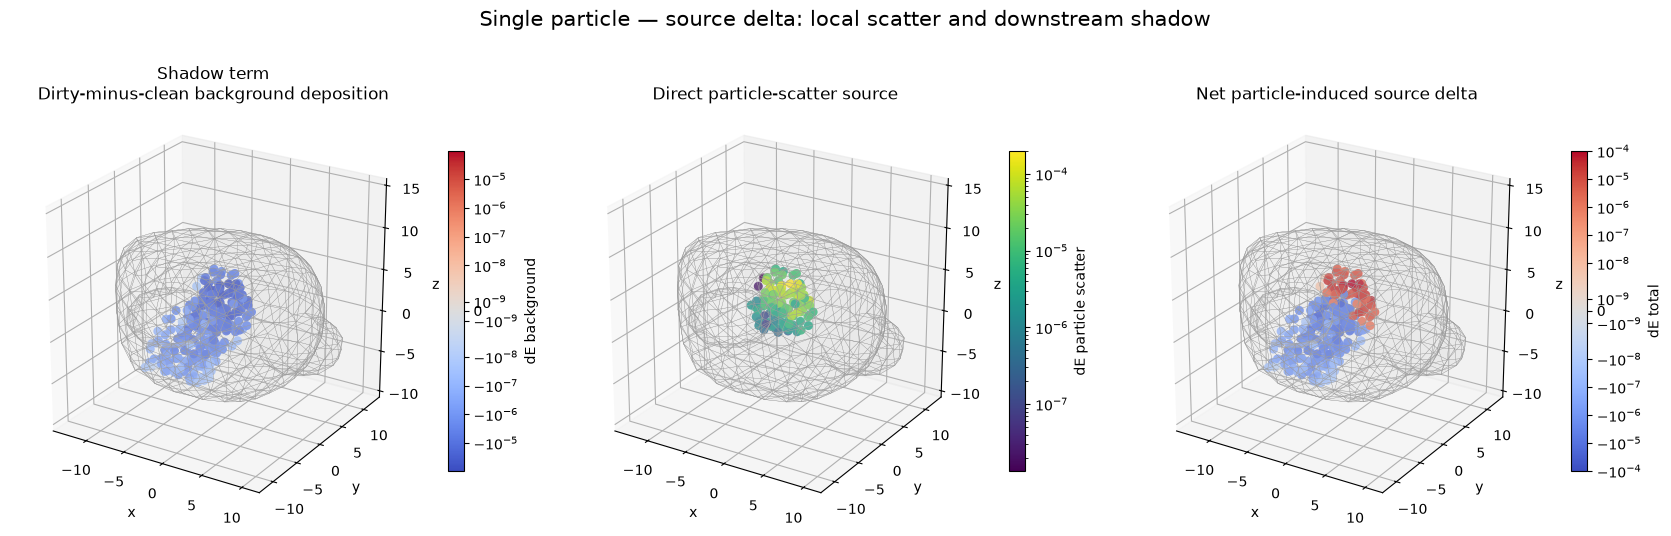

Source-delta totals:
  delta_E_background_elem    = -0.0024286064941864503
  delta_E_particle_scat_elem = 0.002576611086181826
  delta_E_transport_elem     = 0.00014800459199537498
Milestone 5C
Test executed: test_particle_source_deposition_rises_at_entry_then_falls_downstream()

pytest:
../../venv/lib/python3.12/site-packages/gummybear_validation/milestone_05/validation.py . [100%]
============================== 1 passed in 2.56s ===============================

Test proves: Strong particle scattering raises source deposition at particle entry before
             combined attenuation produces a downstream shadow.


In [9]:
plot_source_delta_triptych(
    diff_mesh,
    E_clean_elem=E_clean_elem,
    source_delta=source_delta,
    title="Single particle — source delta: local scatter and downstream shadow",
)

notebook_tools.run_installed_pytest_test(
    m5_validation,
    "test_particle_source_deposition_rises_at_entry_then_falls_downstream",
)


# 6. Multi-particle source-delta figures

Reuse the single-particle scenery (`segments`, `E_clean_elem`, `mat`) for:

- two particles with **no common rays** (lateral),
- two particles with **partial ray overlap** (in-line).


In [10]:
def _events_for_particles(particle_set):
    events_local = intersect_segments_with_particles(
        segments.starts, segments.ends, particle_set
    )
    return sorted(
        list(events_local),
        key=lambda ev: (int(ev.segment_index), float(ev.entry_t), int(ev.particle_index)),
    )


def _path_ids_by_particle(events_local):
    path_to_particles = {}
    for ev in events_local:
        path_id = int(ray_ids[int(ev.segment_index)])
        path_to_particles.setdefault(path_id, set()).add(int(ev.particle_index))
    return path_to_particles


def compute_source_delta_for_particles(particle_set):
    events_local = _events_for_particles(particle_set)
    if not events_local:
        raise AssertionError("No particle intersection events were found.")
    pair_result_local = build_affected_transport_pairs(
        segments,
        particle_set,
        events=events_local,
        mu_s=mat.mu_scatter,
        mu_a=mat.mu_absorption,
    )
    source_delta_local = compute_transport_source_correction(
        diff_mesh,
        pair_result_local,
        E_clean_elem,
        mu_s=mat.mu_scatter,
        mu_a=mat.mu_absorption,
    )
    return events_local, pair_result_local, source_delta_local


## 6.1 Lateral pair — two particles, no common rays


Lateral multi-particle: 84 event(s), 84 pair(s); dual-hit rays=0.


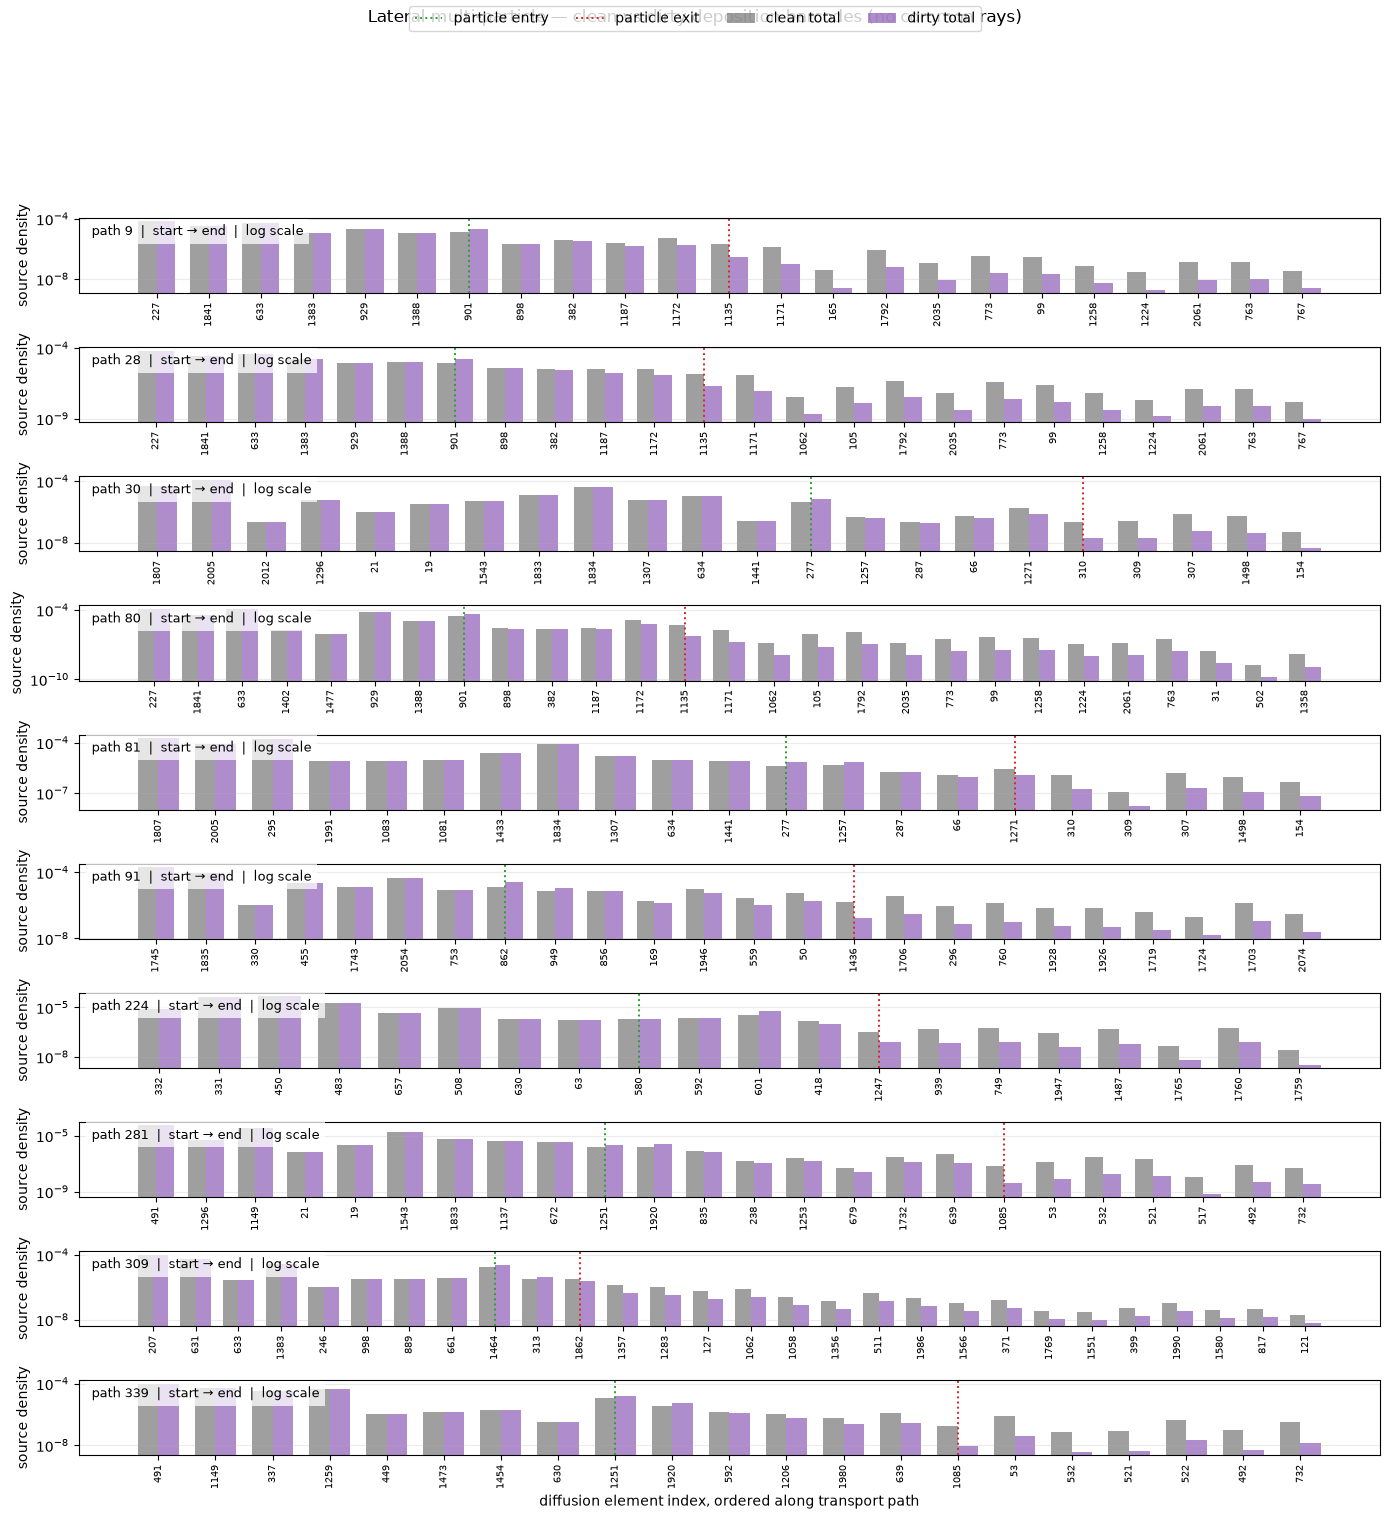

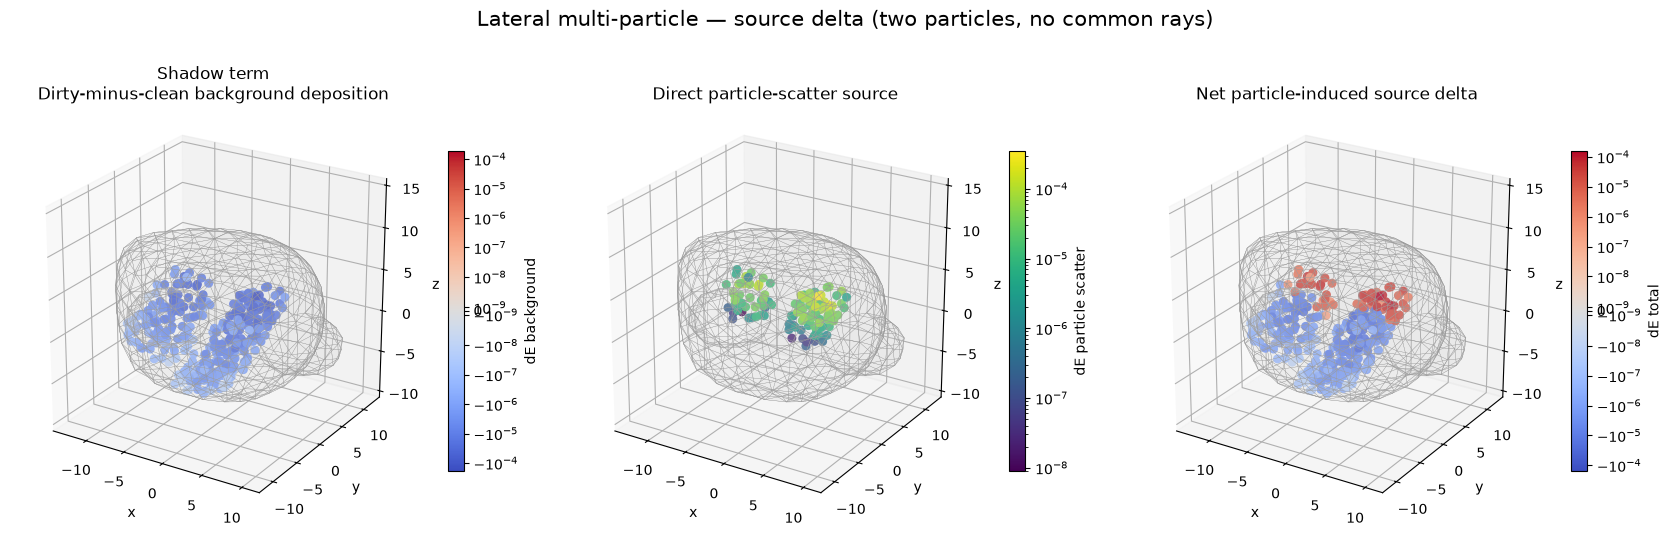

Source-delta totals:
  delta_E_background_elem    = -0.004087484809708799
  delta_E_particle_scat_elem = 0.0043146340670824485
  delta_E_transport_elem     = 0.00022714925737364936


In [11]:
lateral_offset = np.array([4.5, 0.0, 0.0], dtype=float)
particles_multi_lateral = ParticleSet.from_particles([
    ParticleSphere(
        center=c - lateral_offset,
        radius=2.5,
        mu_abs=0.2,
        mu_scat=0.8,
        particle_id="p000_left",
    ),
    ParticleSphere(
        center=c + lateral_offset,
        radius=2.5,
        mu_abs=0.2,
        mu_scat=0.8,
        particle_id="p001_right",
    ),
])
assert particles_multi_lateral.validate()

events_lateral, pair_result_lateral, source_delta_lateral = (
    compute_source_delta_for_particles(particles_multi_lateral)
)
pairs_lateral = tuple(pair_result_lateral.pairs)
path_to_particles_lateral = _path_ids_by_particle(events_lateral)
dual_hit_lateral = sorted(
    pid for pid, idxs in path_to_particles_lateral.items() if idxs >= {0, 1}
)
hit_particle_indices_lateral = sorted({int(ev.particle_index) for ev in events_lateral})

if hit_particle_indices_lateral != [0, 1]:
    raise AssertionError(
        f"Expected both lateral particles to be hit; got {hit_particle_indices_lateral}."
    )
if dual_hit_lateral:
    raise AssertionError(
        f"Lateral placement unexpectedly produced dual-hit rays: {dual_hit_lateral[:10]}"
    )

print(
    f"Lateral multi-particle: {len(events_lateral)} event(s), "
    f"{len(pairs_lateral)} pair(s); dual-hit rays={len(dual_hit_lateral)}."
)

fig, axes = plot_transport_pair_deposition_barcodes(
    pairs_lateral,
    segments,
    events_lateral,
    ray_ids,
    diff_mesh,
    mu_s=mat.mu_scatter,
    mu_a=mat.mu_absorption,
    max_rays=10,
    seed=3,
    random_select=True,
    density=True,
    log_scale=True,
)
fig.suptitle(
    "Lateral multi-particle — clean vs dirty deposition barcodes (no common rays)",
    y=1.01,
)
plt.show()

plot_source_delta_triptych(
    diff_mesh,
    E_clean_elem=E_clean_elem,
    source_delta=source_delta_lateral,
    title="Lateral multi-particle — source delta (two particles, no common rays)",
)


## 6.2 In-line pair — partial ray overlap (some rays hit both)


In-line multi-particle: 69 event(s), 40 pair(s); dual-hit rays=29 (examples [3, 19, 52, 59, 67]).


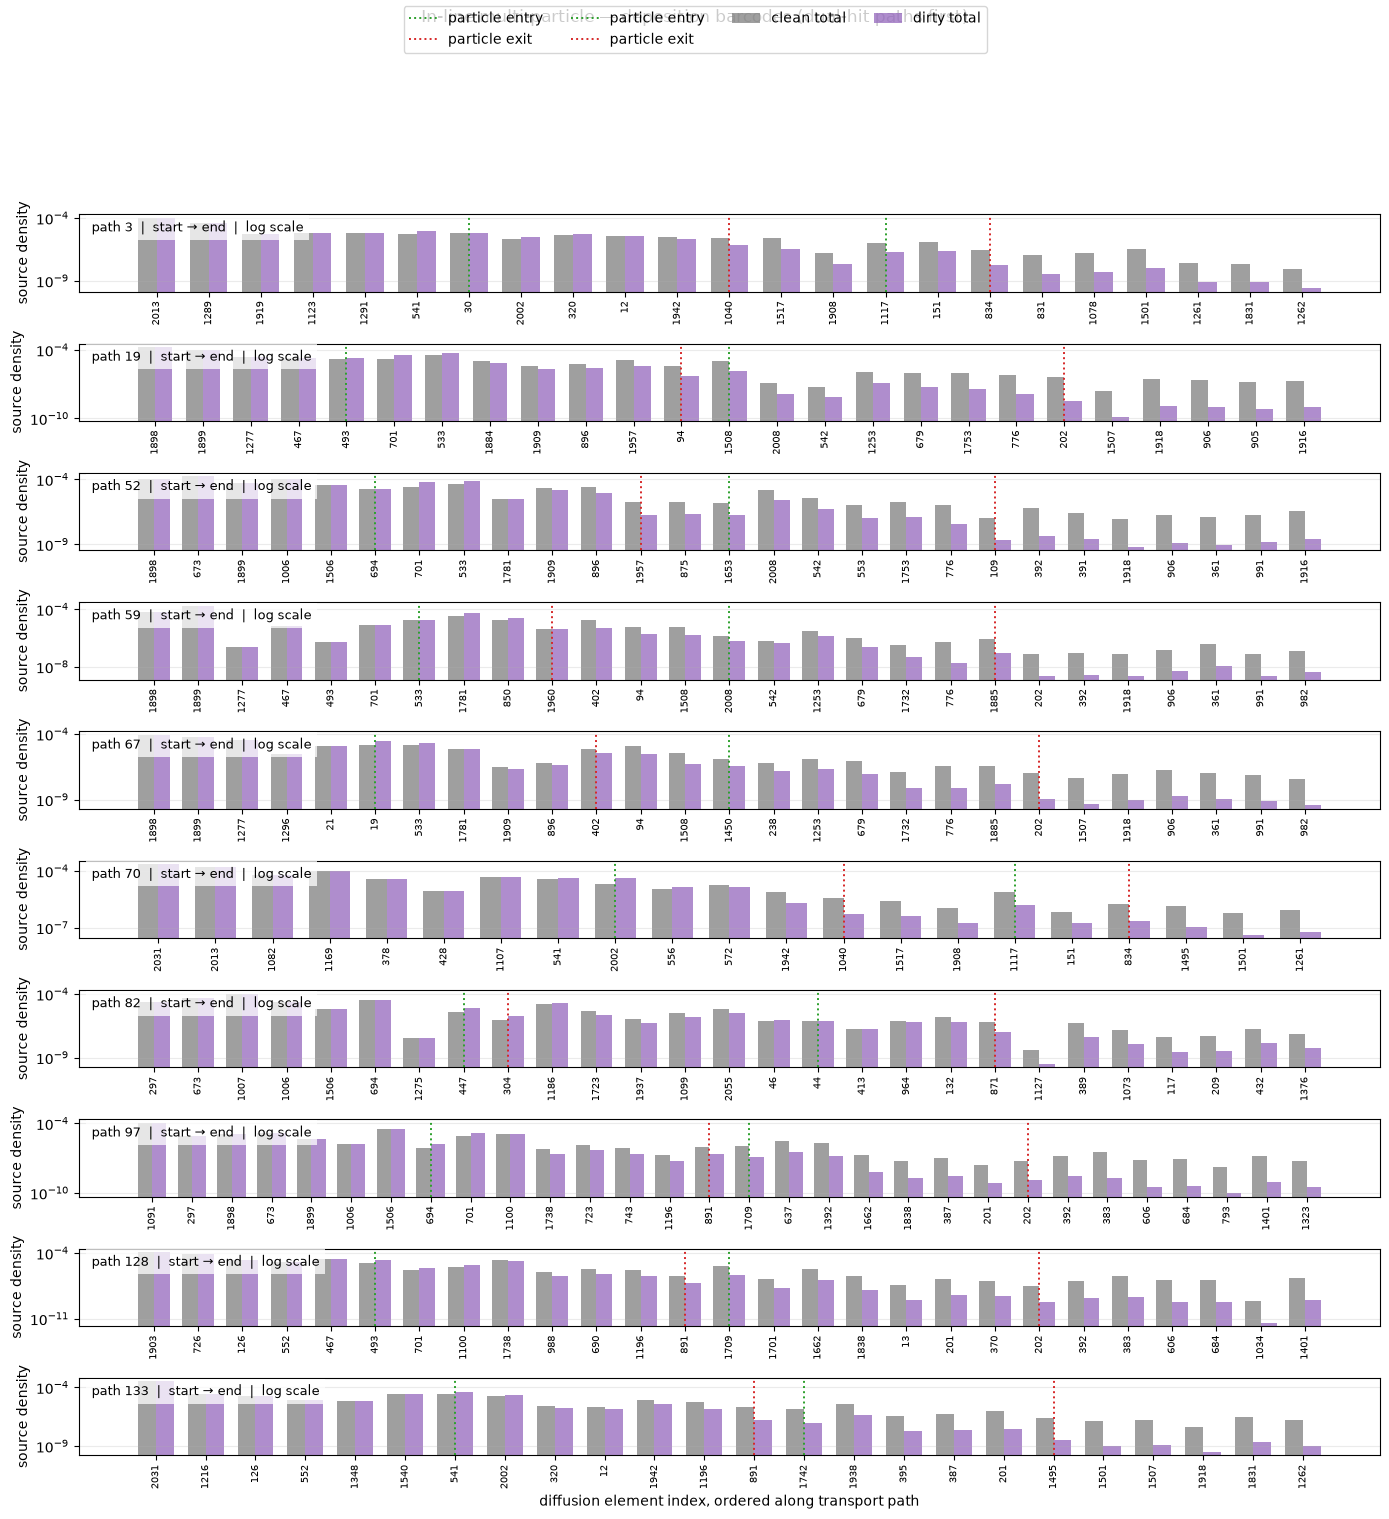

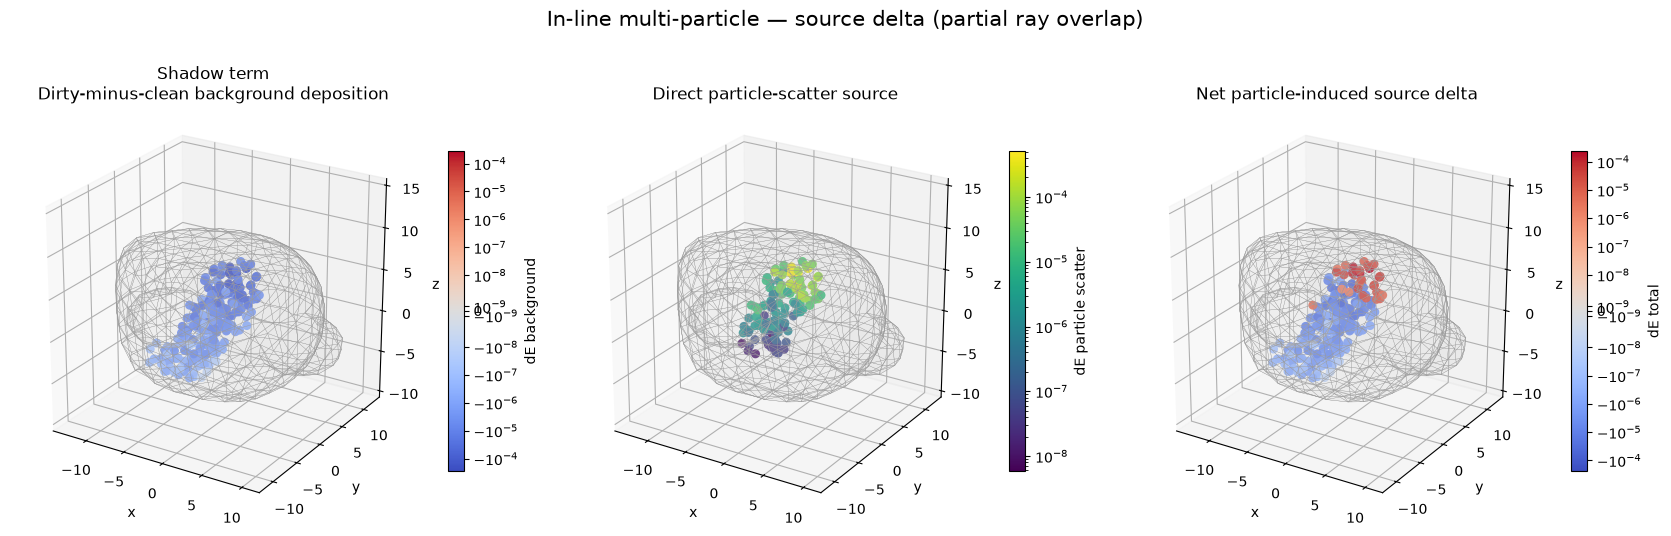

Source-delta totals:
  delta_E_background_elem    = -0.00450150862975851
  delta_E_particle_scat_elem = 0.004736680594659504
  delta_E_transport_elem     = 0.00023517196490099466


In [12]:
light_pos = np.asarray(light.position, dtype=float)
axis = c - light_pos
axis = axis / np.linalg.norm(axis)
inline_half_sep = 2.75
particles_multi_inline = ParticleSet.from_particles([
    ParticleSphere(
        center=c - inline_half_sep * axis,
        radius=2.5,
        mu_abs=0.2,
        mu_scat=0.8,
        particle_id="p000_upstream",
    ),
    ParticleSphere(
        center=c + inline_half_sep * axis,
        radius=2.5,
        mu_abs=0.2,
        mu_scat=0.8,
        particle_id="p001_downstream",
    ),
])
assert particles_multi_inline.validate()

events_inline, pair_result_inline, source_delta_inline = (
    compute_source_delta_for_particles(particles_multi_inline)
)
pairs_inline = tuple(pair_result_inline.pairs)
path_to_particles_inline = _path_ids_by_particle(events_inline)
dual_hit_inline = sorted(
    pid for pid, idxs in path_to_particles_inline.items() if idxs >= {0, 1}
)
hit_particle_indices_inline = sorted({int(ev.particle_index) for ev in events_inline})

if hit_particle_indices_inline != [0, 1]:
    raise AssertionError(
        f"Expected both in-line particles to be hit; got {hit_particle_indices_inline}."
    )
if not dual_hit_inline:
    raise AssertionError(
        "In-line placement produced no transport ray that hits both spheres. "
        "Adjust inline_half_sep / radii or increase n_rays."
    )

dual_set = set(dual_hit_inline)
pairs_inline_ordered = tuple(
    sorted(
        pairs_inline,
        key=lambda pair: (0 if int(pair.path_id) in dual_set else 1, int(pair.path_id)),
    )
)

print(
    f"In-line multi-particle: {len(events_inline)} event(s), "
    f"{len(pairs_inline)} pair(s); dual-hit rays={len(dual_hit_inline)} "
    f"(examples {dual_hit_inline[:5]})."
)

fig, axes = plot_transport_pair_deposition_barcodes(
    pairs_inline_ordered,
    segments,
    events_inline,
    ray_ids,
    diff_mesh,
    mu_s=mat.mu_scatter,
    mu_a=mat.mu_absorption,
    max_rays=10,
    seed=3,
    random_select=False,
    density=True,
    log_scale=True,
)
fig.suptitle(
    "In-line multi-particle — deposition barcodes (dual-hit paths first)",
    y=1.01,
)
plt.show()

plot_source_delta_triptych(
    diff_mesh,
    E_clean_elem=E_clean_elem,
    source_delta=source_delta_inline,
    title="In-line multi-particle — source delta (partial ray overlap)",
)


# Conclusion Milestone 5C

M5C builds a transport-derived source delta from clean/dirty **path** pairs
(one pair per affected `path_id`): background dirty−clean deposition plus
direct particle-scatter deposition.

Figure progression:

1. **Single particle** — entry scatter / downstream shadow.
2. **Two particles, lateral** — both contribute, but no shared rays.
3. **Two particles, in-line** — some rays hit both spheres in sequence
   (still one pair per dual-hit path; two sequential chords inside it).

Diffusion and camera-image consequences follow in M5D.
